<a href="https://colab.research.google.com/github/naathycc/Projeto-trainee-dados-Cati-Jr/blob/feat%2Feda/notebook/house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**House Prices: Predição de Preços de Residências Utilizando Machine Learning**

**Introdução**

O dataset House Prices contém informações sobre aproximadamente 1.460 residências na cidade de Ames, Iowa, sendo descritas por cerca de 80 variáveis relacionadas às características dos imóveis. Neste projeto, os dados serão analisados, limpos e preparados com o objetivo de treinar modelos de Machine Learning capazes de prever o preço de venda de imóveis com base em suas características.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1º passo: coletando os dados.

In [2]:
teste = pd.read_csv('test.csv')
treino = pd.read_csv('train.csv')

2º passo: Primeiras análises:


In [36]:
# Analisando número de colunas e linhas
treino.shape
# Assim, há 1460 linhas e 81 colunas.

(1460, 261)

In [4]:
# Analisando primeiras linhas
treino.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
treino.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
print(f"Média dos preços: {treino['SalePrice'].mean():.2f}")
print(f"Mediana dos preços: {treino['SalePrice'].median():.2f}")
print(f"Moda dos preços: {treino['SalePrice'].mode()[0]:.2f}")

Média dos preços: 180921.20
Mediana dos preços: 163000.00
Moda dos preços: 140000.00


3º passo: Limpeza de dados

**Verificando valores faltantes**

In [7]:
# Observando a porcentagem de valores faltantes:
faltantes = pd.DataFrame({ # criação de dataframe
    'Ausentes': treino.isnull().sum(), # soma de valores faltantes
    'Percentual (%)': round(treino.isnull().mean() * 100, 2) # percentual para valores faltantes.
})

faltantes = faltantes[faltantes['Ausentes'] > 0]
faltantes.sort_values('Percentual (%)', ascending=False)

,Ausentes,Percentual (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


É possível observar que algumas colunas apresentam uma quantidade muito alta de valores ausentes. Para definir a melhor estratégia de tratamento, é necessário investigar o significado de cada variável por meio do arquivo data_description.

A partir dessa análise, foi identificado que diversas colunas, como PoolQC, Alley, Fence e FireplaceQu, representam características que algumas casas não vão possuir. Nesses casos, os valores ausentes não são erros nem falhas na coleta dos dados, sendo, assim, correspondentes à inexistência dessas características no imóvel. Portanto, uma estratégia adequada é substituir os valores ausentes por uma categoria como "None", indicando a ausência do recurso.

Já para variáveis numéricas com poucos valores ausentes, a substituição pela mediana é uma alternativa melhor. Como o dataset apresenta distribuição assimétrica e contém outliers, a mediana é menos influenciada por valores extremos do que a média, preservando melhor as características originais dos dados.


In [8]:
def tratamento_nulos(df):

    df = df.fillna({
        'PoolQC': 'None',
        'MiscFeature': 'None',
        'Alley': 'None',
        'Fence': 'None',
        'FireplaceQu': 'None',
        'GarageType': 'None',
        'GarageFinish': 'None',
        'GarageQual': 'None',
        'GarageCond': 'None',
        'BsmtExposure': 'None',
        'BsmtFinType2': 'None',
        'BsmtQual': 'None',
        'BsmtFinType1': 'None',
        'BsmtCond': 'None'
    })

    df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)

    if 'Electrical' in df.columns:
        df['Electrical'] = df['Electrical'].fillna(
            df['Electrical'].mode()[0]
        )

    df['MasVnrType'] = df['MasVnrType'].fillna('None')
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)
    df['LotFrontage'] = df['LotFrontage'].fillna(
        df['LotFrontage'].median()
    )

    return df

In [9]:
#testando a função tratamento_nulos()
treino = tratamento_nulos(treino)
teste = tratamento_nulos(teste)

**Investigando outliers**

In [10]:
q1 = treino['SalePrice'].quantile(0.25)
q3 = treino['SalePrice'].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
outliers = treino[(treino['SalePrice'] < lim_inf) | (treino['SalePrice'] > lim_sup)] # outliers no preço de venda

# É importante voltar ao arquivo data.descriptions e procurar variáveis interessantes para procurar nos outliers:
# OverallQual: avalia o material e o acabamento da casa.
# OverallCond: avalia a condição da casa.
# LotArea: área disponível.
# GrLivArea: área habitável acima do solo.
# outliers em ordem decrescente considerando as variáveis acima:

outliers[[
    'SalePrice',
    'OverallQual',
    'OverallCond',
    'LotArea',
    'GrLivArea']
].sort_values(
    by = 'SalePrice',
    ascending=False
)

# Foi realizada uma investigação dos outliers identificados na variável
# SalePrice por meio das variáveis OverallQual, OverallCond, LotArea e
# GrLivArea.
# Observou-se que os imóveis com maiores preços apresentam características
# compatíveis com seus valores de venda, como melhor qualidade da construção,
# maior área do terreno e maior área habitável.
# Dessa forma, concluiu-se que esses outliers representam observações
# legítimas do conjunto de dados e não erros de registro. Portanto,
# optei por mantê-los, pois sua remoção poderia eliminar informações
# importantes para o treinamento dos modelos de Machine Learning.

,SalePrice,OverallQual,OverallCond,LotArea,GrLivArea
691,755000,10,6,21535,4316
1182,745000,10,5,15623,4476
1169,625000,10,5,35760,3627
898,611657,9,5,12919,2364
803,582933,9,5,13891,2822
...,...,...,...,...,...
990,348000,8,5,9452,2392
642,345000,8,7,13860,2704
11,345000,9,5,11924,2324
320,342643,9,5,16259,2596


**Verificando duplicatas**

In [11]:
def verificar_duplicatas(df):

    duplicatas = df.duplicated().sum()

    print('Duplicatas encontradas:' ,duplicatas)

    return duplicatas

In [12]:
# testando a função verificar_duplicatas():
verificar_duplicatas(treino)
verificar_duplicatas(teste)
# Não foram encontradas duplicatas nesse dataset. Assim, não vai ser necessário
# fazer nenhum tratamento de dados em relação à isso.

Duplicatas encontradas: 0
Duplicatas encontradas: 0


np.int64(0)

4º passo: Análise exploratória de dados

In [13]:
print(f"O mínimo de preço é: {treino['SalePrice'].min()}")
print(f"O maximo de preço é: {treino['SalePrice'].max()}")
print(f"O desvio padrão é: {treino['SalePrice'].std():.2f}") # Quanto que os valores se afastam da média
q1 = treino['SalePrice'].quantile(0.25)
q3 = treino['SalePrice'].quantile(0.75)
print("1º quartil: ",q1)
print("2º quartil: ",treino['SalePrice'].median())
print("3º quartil: ",q3)
# O primeiro quartil (Q1 = 129.975) indica que 25% dos imóveis
# possuem preço inferior ou igual a aproximadamente 130 mil.
# O segundo quartil (Q2 = 163.000) indica que 50% dos imóveis possuem
# preço inferior ou igual a 163 mil.
# O terceiro quartil (Q3 = 214.000) indica que 75% dos imóveis
# possuem preço inferior ou igual a 214 mil.
# Conclui-se que os preços nesse dataset apresentam valores mínimos
# e máximos muitos distantes entre si e também grande dispersão entre
# os valores, evidenciado pelo grande desvio padrão de 79 mil.

O mínimo de preço é: 34900
O maximo de preço é: 755000
O desvio padrão é: 79442.50
1º quartil:  129975.0
2º quartil:  163000.0
3º quartil:  214000.0


Text(0, 0.5, 'Frequência')

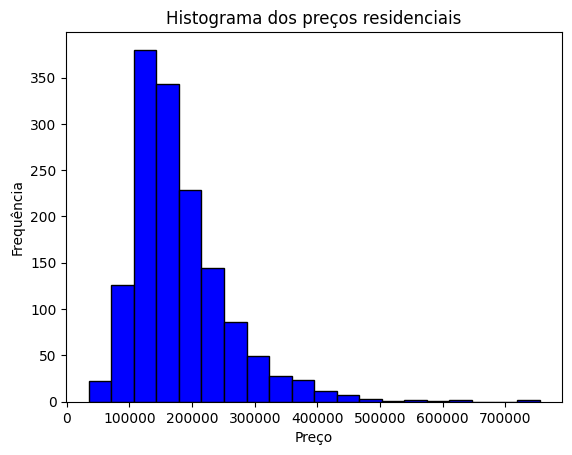

In [14]:
# Histograma para entender a distribuição dos preços
plt.hist(treino['SalePrice'], bins=20, color= 'blue', edgecolor='black')
plt.title("Histograma dos preços residenciais")
plt.xlabel("Preço")
plt.ylabel("Frequência")
# Nesse histograma é possível ver que há uma assimetria a direita, pois a média é maior que
# a mediana e esta é maior que a moda.

Text(0.5, 1.0, 'Boxplot dos preços residenciais')

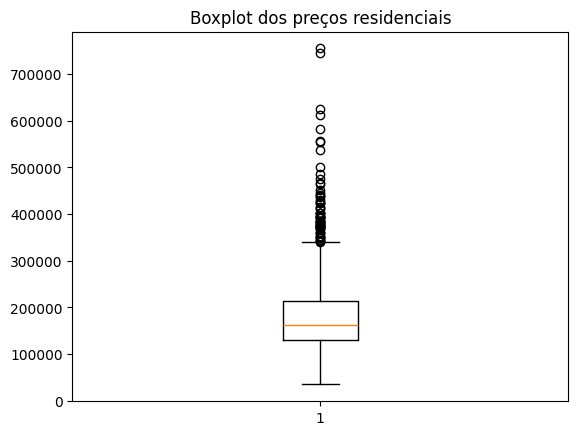

In [15]:
# Boxplot para observar outliers no dataset.
plt.boxplot(treino['SalePrice'])
plt.title("Boxplot dos preços residenciais")
# É possível observar que há muitos outliers acima de aproximadamente
# 350 mil.

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


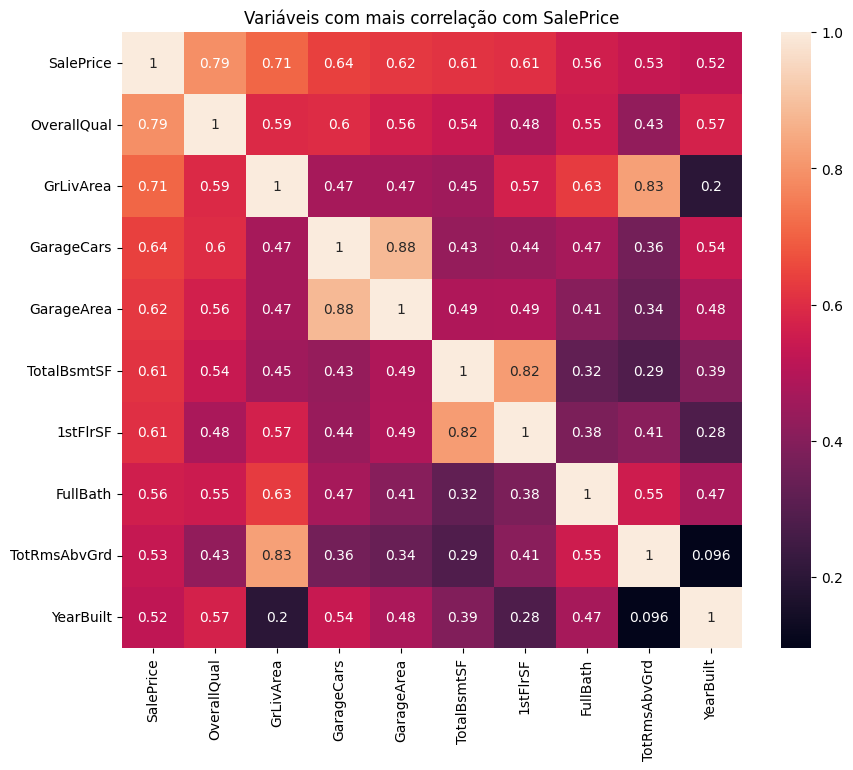

In [16]:
# Visualizando correlações com o heatmap:
correlacao = treino.corr(numeric_only=True) # matriz de correlação com todas as variáveis numéricas.

top_correlacoes = correlacao['SalePrice'].sort_values( # pegando a matriz de correlações
# que já existe do preço e ordenando.
    ascending=False
).head(10)

print(top_correlacoes)
maiores_correlacoes = top_correlacoes.index
plt.figure(figsize=(10, 8))
sns.heatmap(treino[maiores_correlacoes].corr(), annot=True) # como as 12 maiores variáveis se relacionam entre si.
plt.title("Variáveis com mais correlação com SalePrice")
plt.show()
# Com essa análise, é possível saber as variáveis mais correlacionadas com o custo das casas são:
# OverallQual, GrLivArea, GarageCards, GarageArea, TotalBsmtSf, FullBath, TotRmsAbvGrd e YearBuilt.

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64


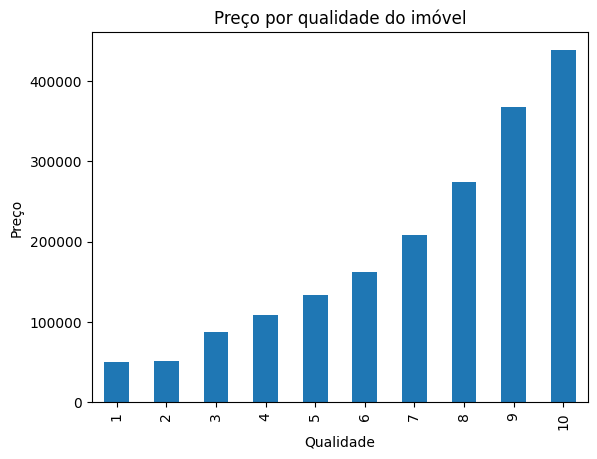

In [17]:
# Relação entre qualidade do imóvel e o preço
qualidade_preco = treino.groupby('OverallQual')['SalePrice'].mean()
print(qualidade_preco)

qualidade_preco.plot(kind='bar')
plt.title('Preço por qualidade do imóvel')
plt.xlabel('Qualidade')
plt.ylabel('Preço')
plt.show()
# É possível observar uma relação clara entre essas duas variáveis, pois
# casas com qualidade superior tem preços bem mais altos que as casas com
# baixa qualidade.


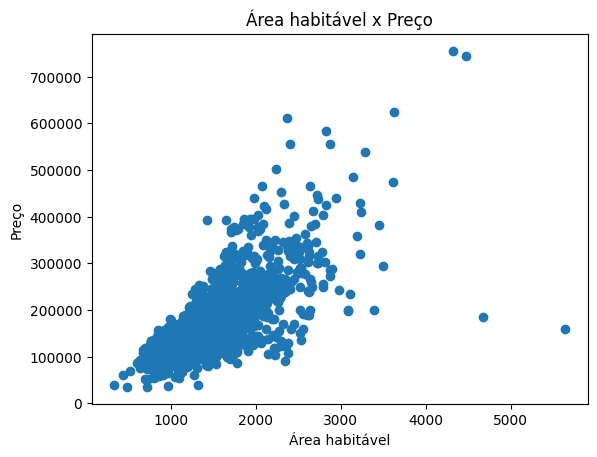

In [18]:
# Relação entre área habitável do imóvel e o preço
plt.scatter(
    treino['GrLivArea'],
    treino['SalePrice']
)

plt.xlabel('Área habitável')
plt.ylabel('Preço')
plt.title('Área habitável x Preço')
plt.show()
# Observa-se uma relação positiva entre a área habitável e o preço dos
# imóveis. Em geral, casas maiores tendem a possuir preços mais elevados.
# Entretanto, a dispersão dos pontos indica que outras variáveis também
# influenciam o valor de venda dos imóveis.

Neighborhood
Blmngtn    194870.882353
Blueste    137500.000000
BrDale     104493.750000
BrkSide    124834.051724
ClearCr    212565.428571
CollgCr    197965.773333
Crawfor    210624.725490
Edwards    128219.700000
Gilbert    192854.506329
IDOTRR     100123.783784
MeadowV     98576.470588
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
NWAmes     189050.068493
NoRidge    335295.317073
NridgHt    316270.623377
OldTown    128225.300885
SWISU      142591.360000
Sawyer     136793.135135
SawyerW    186555.796610
Somerst    225379.837209
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64


<Axes: xlabel='Neighborhood'>

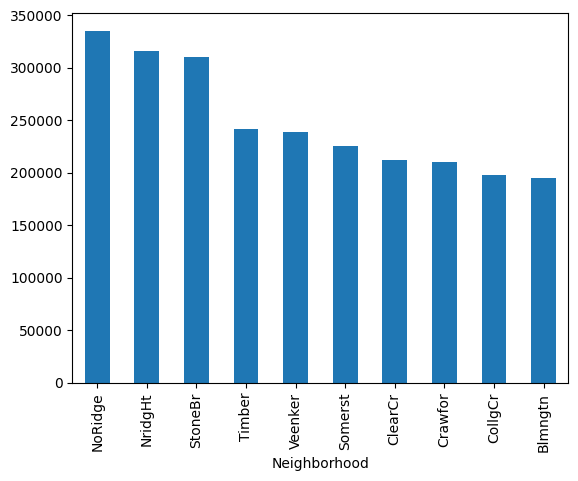

In [19]:
# Vizinhança e preços
vizinhanca_preco = treino.groupby('Neighborhood')['SalePrice'].mean()
print(vizinhanca_preco)

vizinhanca_preco.sort_values(
    ascending=False
).head(10).plot(kind='bar')

# Nessa análise, foi possível ver que os bairros mais caros são:
# NoRidge, NridgHt e StoneBr.
# Já os mais baratos são:
# Crawfor, Collgcr, Blmngtn.
# A diferença entre o mais caro e o mais barato é de 140 mil.
# Mostrando uma grande variação dos preços dependendo do bairro.

5º passo: Preparação para o treinamento da ML.

Os modelos de machine learning tem dificuldade com variáveis categóricas, ou seja aquelas que não são numéricas. Assim, precisamos fazer com que essas variáveis se tornem numéricas.
Isso acontece de duas formas: Label Enconding e One-Hot Enconding.
*   Label Enconding: transformação da coluna em um valor numérico único. Usado quando as variáveis categóricas são ordinais.
*   One-Hot Enconding: converte cada categoria em uma nova variável binária, que é a variável dummy. Há a criação de colunas adicionais. Eficaz para variáveis categóricas nominais e quando o número de colunas é pequeno.



In [20]:
# Descobrindo quantas variáveis categóricas temos no dataset
categoricas = treino.select_dtypes(include='object').columns
print(len(categoricas))
# Como temos 43 variáveis categóricas, vou filtrar elas em ordinais e nominais
# para aplicar one-hot ou label encoding.
treino.info()

43
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  Overa

In [21]:
# voltando ao arquivo data.descriptions:
# VARIÁVEIS ORDINAIS:
# LotShape, Utilities, LandSlope,
# ExterQual, ExterCond, BsmtQual,
# BsmtCond, BsmtExposure, BsmtFinType1,
# BsmtFinType2, HeatingQC, Electrical,
# KitchenQual, Functional, FireplaceQu,
# GarageFinish, GarageQual, GarageCond,
# PavedDrive, PoolQC, Fence, OverallQual,
# OverallCond
# VARIÁVEIS NOMINAIS
# MSZoning, Street, Alley,
# LandContour, LotConfig, Neighborhood,
# Condition1, Condition2, BldgType,
# HouseStyle, RoofStyle, RoofMatl,
# Exterior1st, Exterior2nd, MasVnrType,
# Foundation, Heating, CentralAir,
# GarageType, MiscFeature, SaleType,
# SaleCondition

In [22]:
# Algumas variáveis possuem ordem natural e serão convertidas
# para valores numéricos (Ordinal Encoding). As variáveis
# nominais serão transformadas posteriormente utilizando
# One-Hot Encoding.
# Variáveis escolhidas:
# ExterQual, ExterCond, KitchenQual
# BsmtQual, GarageQual, GarageCond
# HeatingQC

def tratamento_ordinais(df):

    ordem = {
        'None': 0,
        'Po': 1,
        'Fa': 2,
        'TA': 3,
        'Gd': 4,
        'Ex': 5
    }

    colunas_ordem = [
        'ExterQual',
        'ExterCond',
        'KitchenQual',
        'BsmtQual',
        'GarageQual',
        'GarageCond',
        'HeatingQC'
    ]

    for coluna in colunas_ordem:
        df[coluna] = df[coluna].map(ordem)

    return df

In [23]:
#testando tratamento_ordinais()
treino = tratamento_ordinais(treino)
teste = tratamento_ordinais(teste)

In [26]:
#One-hot enconding
def one_hot(df, categoricas):

    df = pd.get_dummies(
        df,
        columns=categoricas,
        drop_first=True
    )

    return df

In [27]:
# Testando one_hot()
treino = one_hot(treino, categoricas)
teste = one_hot(teste, categoricas)

In [29]:
# Alinhamento de colunas
# garantindo que as duas tenham exatamente as mesmas colunas
# se uma só existir no treino, ela passa a existir no teste.
def alinhar_colunas(treino, teste):

    treino, teste = treino.align(
        teste,
        join='left',
        axis=1,
        fill_value=0
    )

    return treino, teste

In [30]:
# testando alinhar_colunas()
treino, teste = alinhar_colunas(treino, teste)

In [31]:
# Verificando se ainda há variáveis categóricas
def encontrar_categoricas(df):

    return df.select_dtypes(
        include='object'
    ).columns

In [34]:
# testando a função encontrar_categoricas
categoricas_treino = encontrar_categoricas(treino)
categoricas_teste = encontrar_categoricas(teste)
print("Categóricas do treino: ", len(categoricas_treino))
print("Categóricas do teste: ", len(categoricas_teste))


Categóricas do treino:  0
Categóricas do teste:  0
